# Tarea 5 - Regresión Lineal

**Objetivo**: Aplicar técnicas de regresión lineal múltiple, selección de variables, diagnóstico del
modelo y evaluación de supuestos, utilizando un dataset de vehículos con características
técnicas y de rendimiento.

---

## 1. Realizar un análisis exploratorio inicial para las variables.

In [1]:
# Librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_excel('CarData.xlsx')
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           200 non-null    float64
 1   cylinders     200 non-null    int64  
 2   displacement  200 non-null    float64
 3   horsepower    200 non-null    float64
 4   weight        200 non-null    float64
 5   acceleration  200 non-null    float64
 6   model_year    200 non-null    int64  
 7   origin        200 non-null    object 
dtypes: float64(5), int64(2), object(1)
memory usage: 12.6+ KB
None


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,30.057096,8,1055.032243,130.733621,3248.357077,11.811145,73,europe
1,33.703956,6,1098.053171,136.823536,2930.867849,13.801250,81,japan
2,30.062669,6,1229.912399,152.491537,3323.844269,15.010487,82,usa
3,26.803516,6,1183.949939,151.614062,3761.514928,15.093961,71,japan
4,36.101853,6,650.243099,78.669919,4882.923313,14.099869,80,usa


A primer vistazo de nuestro dataser, podemos notar que contamos con 8 columnas referentes a caracteristicas tecnicas de distintos vehiculos, y se cuenta con 200 registros de los cuales no hay presencia de datos nulos a simple vista (no se puede descartar que existan datos faltantes codificados de otra forma). En las variables numericas tenemos las millas por galon, numero de cilindros, desplazamiento, caballos de fuerza, peso del vehiculo, aceleracion y año del modelo (usando unicamente los ultimos 2 digitos). Por el lado de las variables categoricas, unicamente contamos con el pais/region de origen del vehiculo. 

In [3]:
# Analisis de duplicados por columna

for col in df.columns:
    num_duplicates = df.duplicated(subset=[col]).sum()
    print(f'Número de duplicados en la columna "{col}": {num_duplicates}')

Número de duplicados en la columna "mpg": 0
Número de duplicados en la columna "cylinders": 197
Número de duplicados en la columna "displacement": 0
Número de duplicados en la columna "horsepower": 0
Número de duplicados en la columna "weight": 0
Número de duplicados en la columna "acceleration": 0
Número de duplicados en la columna "model_year": 187
Número de duplicados en la columna "origin": 197


In [4]:
# Valores unicos en columnas con alto indice de duplicados
columns = ['cylinders', 'model_year', 'origin']

for col in columns:
    unique_values = df[col].unique()
    print(f'Valores unicos en la columna "{col}": {unique_values}')

Valores unicos en la columna "cylinders": [8 6 4]
Valores unicos en la columna "model_year": [73 81 82 71 80 72 79 74 77 75 76 78 70]
Valores unicos en la columna "origin": ['europe' 'japan' 'usa']


In [5]:
df[["mpg", 'displacement', 'horsepower', 'weight', 'acceleration']].describe()

,mpg,displacement,horsepower,weight,acceleration
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,32.239250,981.405789,122.576046,2989.614517,14.828690
std,3.134706,236.921621,29.610114,484.508546,1.988084
min,22.047964,157.101781,22.761980,1690.127448,10.056711
25%,30.072531,813.063115,101.824874,2647.436163,13.412243
50%,32.274266,976.141906,122.365180,3004.528837,14.844800
75%,34.163512,1132.206015,140.616934,3257.717983,16.144176
max,41.104820,1874.121402,235.581945,4882.923313,21.157762


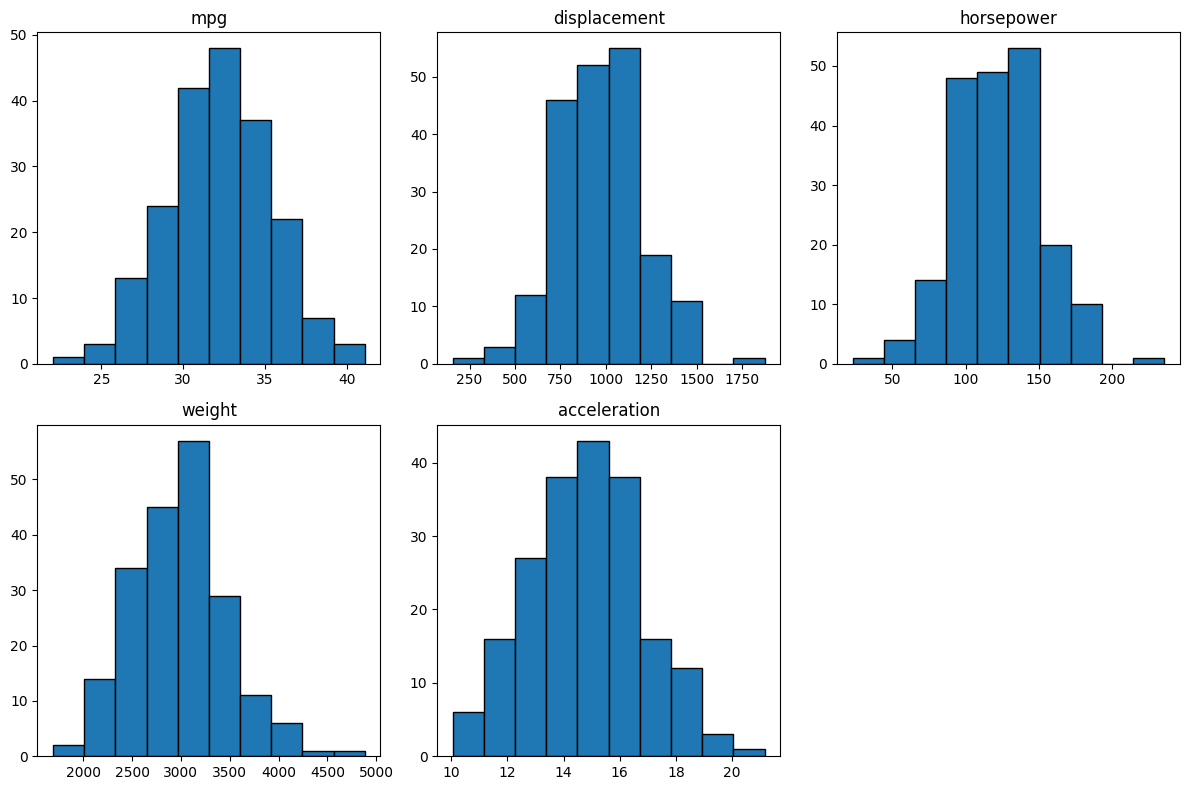

In [6]:
df[["mpg", 'displacement', 'horsepower', 'weight', 'acceleration']].hist(figsize=(12,8), edgecolor='black', grid=False, layout=(2,3))
plt.tight_layout()
plt.show()

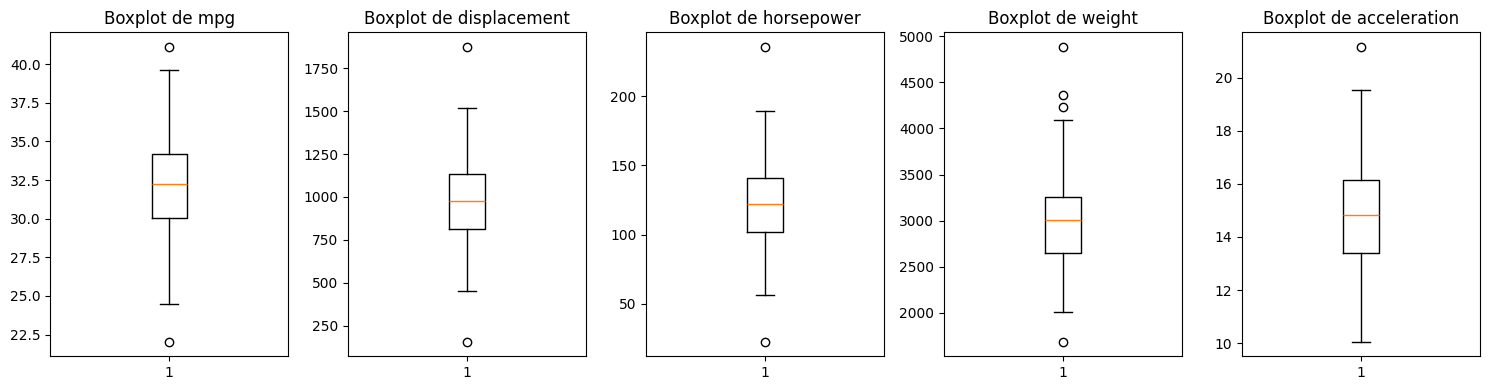

In [7]:
# boxplot por cada variable
plt.figure(figsize=(15,4))

plt.subplot(1, 5, 1)
plt.boxplot(x=df["mpg"])
plt.title('Boxplot de mpg')

plt.subplot(1, 5, 2)
plt.boxplot(x=df["displacement"])
plt.title('Boxplot de displacement')

plt.subplot(1, 5, 3)
plt.boxplot(x=df["horsepower"])
plt.title('Boxplot de horsepower')

plt.subplot(1, 5, 4)
plt.boxplot(x=df["weight"])
plt.title('Boxplot de weight')

plt.subplot(1, 5, 5)
plt.boxplot(x=df["acceleration"])
plt.title('Boxplot de acceleration')

plt.tight_layout()
plt.show()

In [8]:
# eliminacion de outliers
df_clean = df.copy()
for col in df.select_dtypes(include=np.number).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    
df = df_clean.reset_index(drop=True)

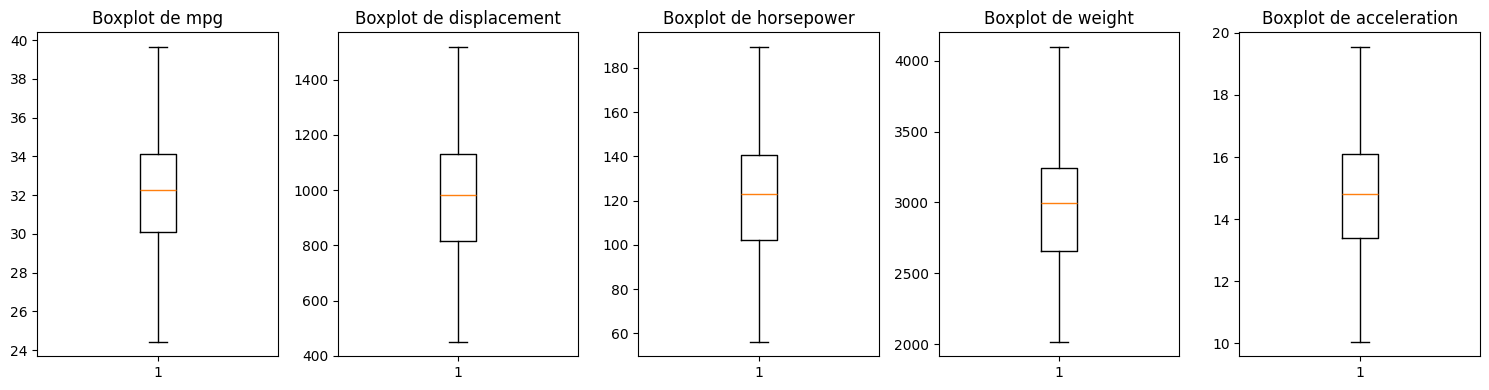

In [9]:
# boxplot por cada variable
plt.figure(figsize=(15,4))

plt.subplot(1, 5, 1)
plt.boxplot(x=df["mpg"])
plt.title('Boxplot de mpg')

plt.subplot(1, 5, 2)
plt.boxplot(x=df["displacement"])
plt.title('Boxplot de displacement')

plt.subplot(1, 5, 3)
plt.boxplot(x=df["horsepower"])
plt.title('Boxplot de horsepower')

plt.subplot(1, 5, 4)
plt.boxplot(x=df["weight"])
plt.title('Boxplot de weight')

plt.subplot(1, 5, 5)
plt.boxplot(x=df["acceleration"])
plt.title('Boxplot de acceleration')

plt.tight_layout()
plt.show()

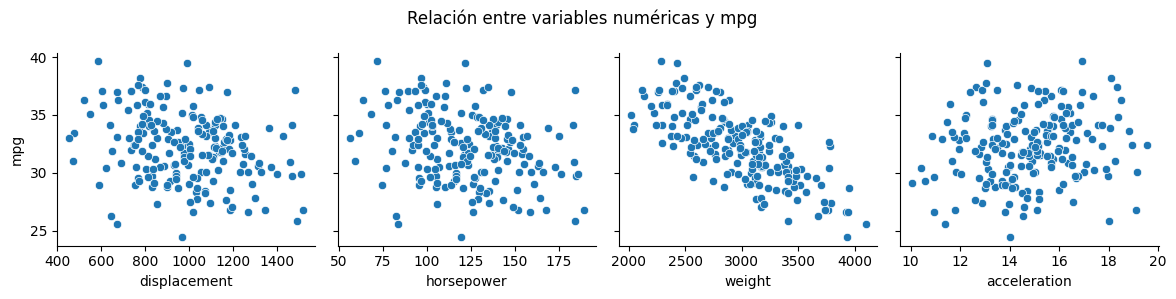

In [10]:
sns.pairplot(df, x_vars=['displacement', 'horsepower', 'weight', 'acceleration'], y_vars=["mpg"], height=3)
plt.suptitle('Relación entre variables numéricas y mpg')
plt.tight_layout()
plt.show()

<Axes: >

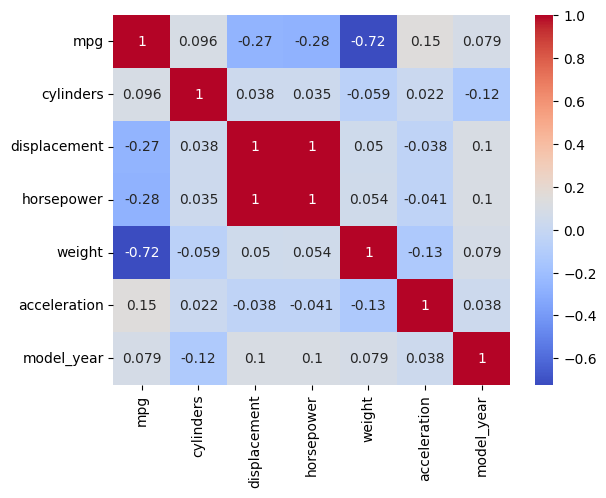

In [11]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

---

## 2. Ajustar un modelo de regresión múltiple donde la variable dependiente sea mpg (rendimiento del automóvil) y las independientes el resto. La variable origin se debecodificar y declararla como variable dummy

In [12]:
x = df[['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin']]
x = pd.get_dummies(x, columns=['origin'])
columns = x.columns

x = StandardScaler().fit_transform(x)

y = df['mpg']

In [13]:
modelo = LinearRegression()
modelo.fit(x, y)
print("Intercepto:" , modelo.intercept_)
print("Coeficientes:" , modelo.coef_)

Intercepto: 32.219283334143576
Coeficientes: [ 0.23726036  2.44245755 -3.18013099 -2.08127538  0.11080638  0.49492179
  0.03603644 -0.09843671  0.06002796]


---

## 3. Interpretar:
- a) Calidad de ajuste,
- b) Error estándar de estimación
- c) ¿Qué variable influye más en el rendimiento?
- d) ¿Cómo afecta el año del modelo al mpg?
- e) ¿Qué sucede al controlar por peso y potencia?
- f) ¿El origen impacta el rendimiento?

In [14]:
y_pred = modelo.predict(x)
residuos = y - y_pred

n = len(y)
p = x.shape[1]
mse = mean_squared_error(y, y_pred)

#### a) Calidad de ajuste

In [15]:
r2_test = modelo.score(x, y)
r2_adj = 1 - (1 - r2_test) * (n - 1) / (n - p - 1)

print(f"R^2: {r2_test:.4f}")
print(f"R^2 ajustado: {r2_adj:.4f}")

R^2: 0.6157
R^2 ajustado: 0.5967


#### b) Error estándar de estimación

In [16]:
rmse = np.sqrt(mse)
se = np.sqrt(np.sum(residuos**2) / (n - p - 1))

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"Error estándar: {se:.4f}")

MSE: 3.3270
RMSE: 1.8240
Error estándar: 1.8735


#### c) ¿Qué variable influye más en el rendimiento?

In [17]:
coef_df = pd.DataFrame({
    "variable": columns,
    "coeficiente": abs(modelo.coef_)
})

coef_df.sort_values("coeficiente", ascending=False)

,variable,coeficiente
2,horsepower,3.180131
1,displacement,2.442458
3,weight,2.081275
5,model_year,0.494922
0,cylinders,0.237260
4,acceleration,0.110806
7,origin_japan,0.098437
8,origin_usa,0.060028
6,origin_europe,0.036036


#### d) ¿Cómo afecta el año del modelo al mpg?

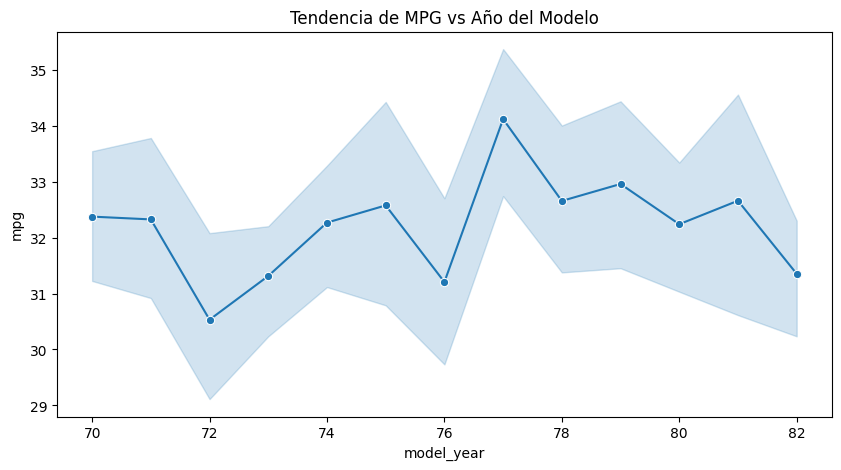

In [18]:
plt.figure(figsize=(10,5))
sns.lineplot(data=df, x="model_year", y="mpg", marker="o")
plt.title("Tendencia de MPG vs Año del Modelo")
plt.show()

La logica nos diría que cada año que pasa, el rendimiento de los autos en cuanto a millas por galon deberia de aumentar, pero de acruerdo a nuestro modelo, la variable presenta un coeficiente de tan solo 0.5, pero a lo que se observa en la grafica, el aumento no es muy significativo con los años, salvo por el salto que se da del 76 al 77, pero se puede ver que tenemos valores 

#### e) ¿Qué sucede al controlar por peso y potencia?

En el caso del modelo generado, peso (weight) y potencia (horsepower) estan entre las 3 variables que mas aportan al modelo, por lo que tienen gran relevancia en cuanto a cuanto gasta un auto en millas por galon.

#### f) ¿El origen impacta el rendimiento?

De acuerdo a los resultados, el origen fue de las variables menos importantes para el modelo, ya que estuvieron por debajo de 0.1 en su valor de coeficiente.

---

## 4. Evaluar supuestos del modelo:
- a) Residuales contra predichos
- b) Linealidad
- c) Normalidad de residuos

#### a) Residuales contra predichos

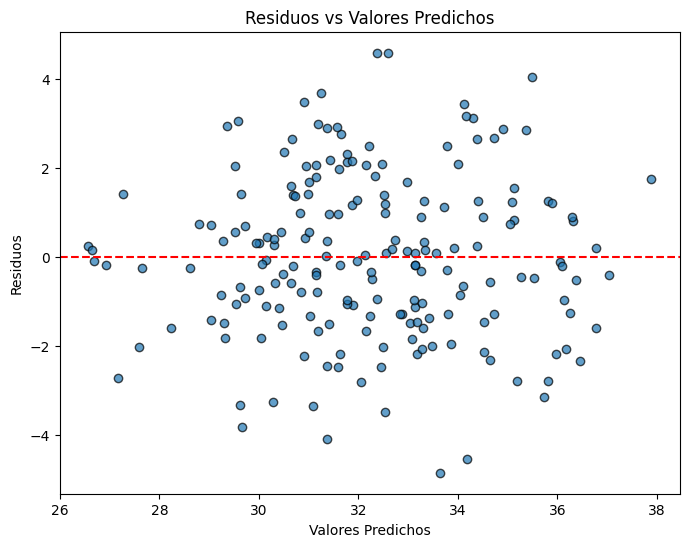

In [19]:
plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuos, edgecolor='k', alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuos vs Valores Predichos')
plt.xlabel('Valores Predichos')
plt.ylabel('Residuos')
plt.show()

### b) Linealidad

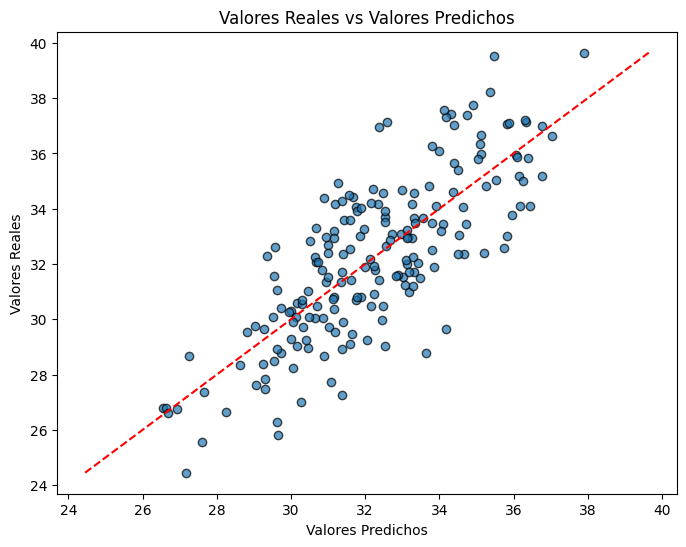

In [20]:
plt.figure(figsize=(8,6))
plt.scatter(y_pred, y, edgecolor='k', alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')
plt.title('Valores Reales vs Valores Predichos')
plt.xlabel('Valores Predichos')
plt.ylabel('Valores Reales')
plt.show()

### c) Normalidad de residuos

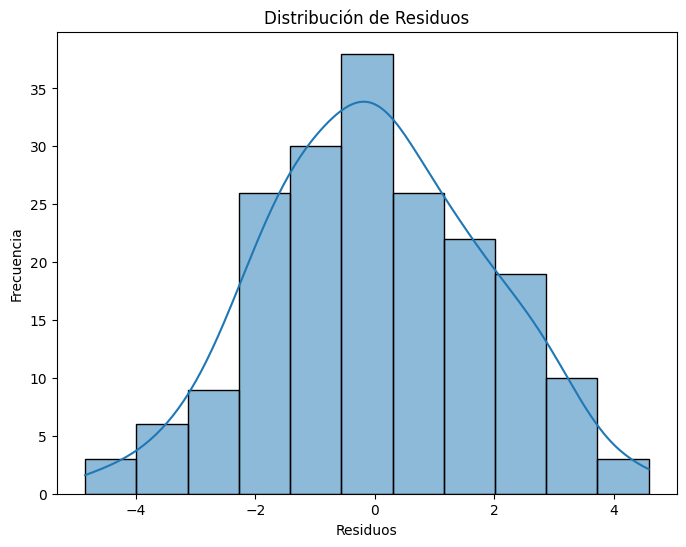

In [21]:
plt.figure(figsize=(8,6))
sns.histplot(residuos, kde=True, edgecolor='black')
plt.title('Distribución de Residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.show()

---

## 5. Proponer una mejora del modelo
- a) Selección de variables (AIC)
- b) Interacciones (para incorporar en el modelo de regresión, simplemente
multiplique las variables correspondientes en el código directamente, sin generar
la variable).

#### a) Selección de variables (AIC)

In [22]:
sfs = SequentialFeatureSelector(LinearRegression(), n_features_to_select='auto', direction='forward', scoring='neg_mean_squared_error', cv=5)
sfs.fit(x, y)
sfs.get_support()
selected_features = [columns[i] for i in range(len(columns)) if sfs.get_support()[i]]
print("Características seleccionadas:", selected_features)

Características seleccionadas: ['cylinders', 'horsepower', 'weight', 'model_year']


In [23]:
x = df[['cylinders', 'horsepower', 'weight', 'model_year']]
x = StandardScaler().fit_transform(x)
y = df['mpg']

In [24]:
modelo_aic = LinearRegression()
modelo_aic.fit(x, y)
y_pred_aic = modelo_aic.predict(x)
residuos_aic = y - y_pred_aic
n = len(y)
p = x.shape[1]
mse_aic = mean_squared_error(y, y_pred_aic)

In [25]:
r2_test = modelo_aic.score(x, y)
r2_adj = 1 - (1 - r2_test) * (n - 1) / (n - p - 1)
rmse = np.sqrt(mse_aic)
se = np.sqrt(np.sum(residuos_aic**2) / (n - p - 1))

print(f"R^2: {r2_test:.4f}")
print(f"R^2 ajustado: {r2_adj:.4f}")
print(f"MSE: {mse_aic:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"Error estándar: {se:.4f}")

R^2: 0.6103
R^2 ajustado: 0.6020
MSE: 3.3739
RMSE: 1.8368
Error estándar: 1.8612


---

## 6. Haga un resumen de lo hecho y lo obtenido.

A lo largo de este analisis, pudimos ver las caracteristicas y tendencias de las variables que conformaban este dataset para darles un previo tratamiento antes de generar un modelo de regresion lineal y que no existieran problemas de ineficiencias por valores atipicos. Una vez generado el modelo con todas las variables, se puedo observar que el rendimiento de este en cuanto a la prediccion de millas por galon no era tan bueno como se hubiese esperado, ya que el R^2 ajustado fue de apenas 0.59, por lo que se decidio aplicar una seleccion de variables usando AIC para mejorar el modelo, y aunque el R^2 ajustado no mejoro mucho (0.60), se pudo conseguir un modelo mas simple con menos variables y que aun asi mantuviera un rendimiento similar.